In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
drivers = pd.read_csv('../data/raw/drivers.csv', na_values=['\\N'])
races = pd.read_csv('../data/raw/races.csv', na_values=['\\N'])
results = pd.read_csv('../data/raw/results.csv', na_values=['\\N'])
constructors = pd.read_csv('../data/raw/constructors.csv', na_values=['\\N'])
status = pd.read_csv('../data/raw/status.csv', na_values=['\\N'])

In [3]:
results.isnull().sum()

resultId               0
raceId                 0
driverId               0
constructorId          0
number                 6
grid                   0
position           10953
positionText           0
positionOrder          0
points                 0
laps                   0
time               19079
milliseconds       19079
fastestLap         18507
rank               18249
fastestLapTime     18507
fastestLapSpeed    18507
statusId               0
dtype: int64

In [4]:
drivers['dob'] = pd.to_datetime(drivers['dob'])
races['date'] = pd.to_datetime(races['date'])
drivers['dob'].dtype
races['date'].dtype

dtype('<M8[us]')

In [5]:
races['date'].dtype

dtype('<M8[us]')

In [6]:
races_subset = races[['raceId', 'year', 'round', 'circuitId', 'name', 'date']].rename(columns={'name': 'race_name'})
drivers_subset = drivers[['driverId', 'driverRef', 'forename', 'surname', 'nationality', 'dob']]
constructors_subset = constructors[['constructorId', 'name']].rename(columns={'name': 'constructor_name'})
status_subset = status[['statusId', 'status']]

master = results.merge(races_subset, on='raceId', how='left')
master = master.merge(drivers_subset, on='driverId', how='left')
master = master.merge(constructors_subset, on='constructorId', how='left')
master = master.merge(status_subset, on='statusId', how='left')

print(master.shape)
assert master.shape[0] == results.shape[0], "Row count badal gaya — kisi table me duplicate keys hain!"

(26759, 30)


In [7]:
master.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,circuitId,race_name,date,driverRef,forename,surname,nationality,dob,constructor_name,status
0,1,18,1,1,22.0,1,1.0,1,1,10.0,...,1,Australian Grand Prix,2008-03-16,hamilton,Lewis,Hamilton,British,1985-01-07,McLaren,Finished
1,2,18,2,2,3.0,5,2.0,2,2,8.0,...,1,Australian Grand Prix,2008-03-16,heidfeld,Nick,Heidfeld,German,1977-05-10,BMW Sauber,Finished
2,3,18,3,3,7.0,7,3.0,3,3,6.0,...,1,Australian Grand Prix,2008-03-16,rosberg,Nico,Rosberg,German,1985-06-27,Williams,Finished
3,4,18,4,4,5.0,11,4.0,4,4,5.0,...,1,Australian Grand Prix,2008-03-16,alonso,Fernando,Alonso,Spanish,1981-07-29,Renault,Finished
4,5,18,5,1,23.0,3,5.0,5,5,4.0,...,1,Australian Grand Prix,2008-03-16,kovalainen,Heikki,Kovalainen,Finnish,1981-10-19,McLaren,Finished


In [8]:
master[["forename", "surname", "race_name", "year", "positionText", "status"]].sample(5)

,forename,surname,race_name,year,positionText,status
13109,Keke,Rosberg,Austrian Grand Prix,1978,N,+7 Laps
2515,Ralf,Schumacher,Italian Grand Prix,2002,R,Engine
6128,Paul,Belmondo,San Marino Grand Prix,1992,13,+3 Laps
22667,Felipe,Nasr,Canadian Grand Prix,2015,16,+2 Laps
15292,Denny,Hulme,United States Grand Prix,1973,4,Finished


In [9]:
master.to_csv("../data/processed/master_results.csv", index=False)

In [10]:
master["driver_name"] = master["forename"] + ' ' + master["surname"]

In [11]:
wins = master[master["position"] == 1]

In [12]:
win_counts = wins.groupby("driver_name").size().sort_values(ascending=False)
top15_wins = win_counts.head(15)
print(top15_wins)

driver_name
Lewis Hamilton        105
Michael Schumacher     91
Max Verstappen         63
Sebastian Vettel       53
Alain Prost            51
Ayrton Senna           41
Fernando Alonso        32
Nigel Mansell          31
Jackie Stewart         27
Niki Lauda             25
Jim Clark              25
Juan Fangio            24
Nelson Piquet          23
Nico Rosberg           23
Damon Hill             22
dtype: int64


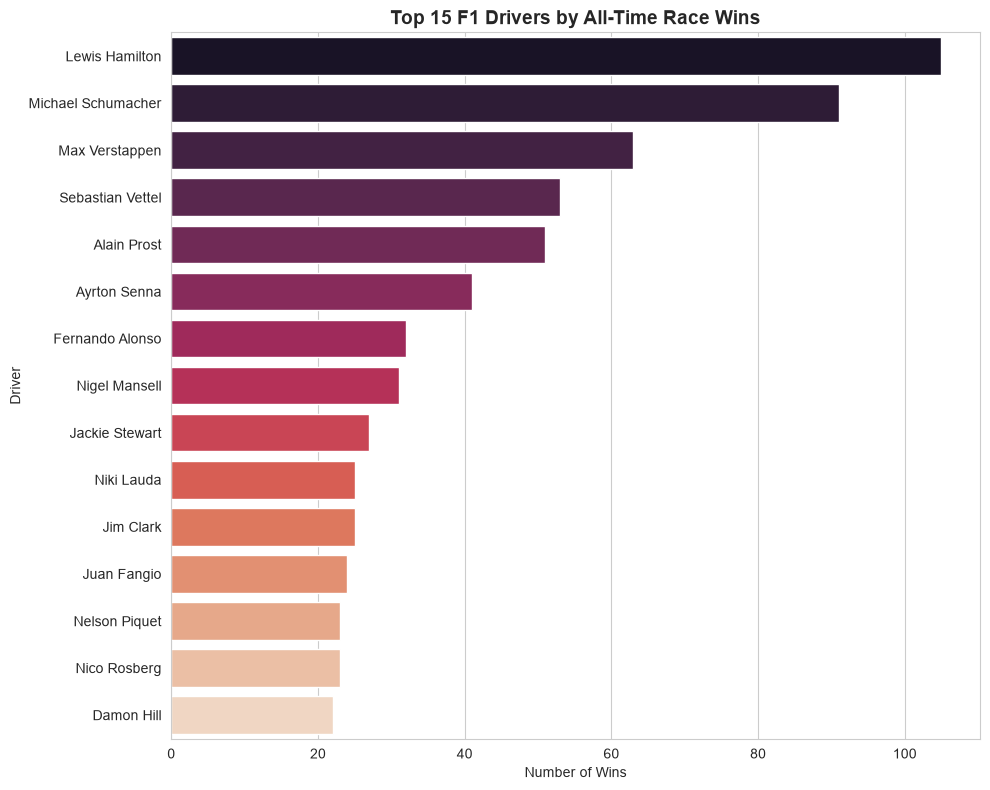

In [13]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 8))
sns.barplot(x=top15_wins.values, y=top15_wins.index, palette="rocket", hue=top15_wins.index, legend=False)

plt.title("Top 15 F1 Drivers by All-Time Race Wins", fontsize=14, fontweight="bold")
plt.xlabel("Number of Wins")
plt.ylabel("Driver")
plt.tight_layout()
plt.show()

In [14]:
constructor_wins = wins.groupby(['constructor_name', 'year']).size().reset_index(name='wins')

In [15]:
constructor_wins.head(10)

,constructor_name,year,wins
0,Alfa Romeo,1950,6
1,Alfa Romeo,1951,5
2,AlphaTauri,2020,1
3,Alpine F1 Team,2021,1
4,BMW Sauber,2008,1
5,BRM,1959,1
6,BRM,1962,4
7,BRM,1963,2
8,BRM,1964,2
9,BRM,1965,3


In [16]:
constructor_wins['decade'] = (constructor_wins['year'] // 10) * 10

In [17]:
top_constructors = wins.groupby('constructor_name').size().sort_values(ascending=False).head(7).index

In [18]:
filtered = constructor_wins[constructor_wins['constructor_name'].isin(top_constructors)]

In [19]:
decade_wins = filtered.groupby(['decade', 'constructor_name'])['wins'].sum().reset_index()

pivot = decade_wins.pivot_table(index='decade', columns='constructor_name', values='wins', fill_value=0)

In [20]:
pivot

constructor_name,Ferrari,McLaren,Mercedes,Red Bull,Renault,Team Lotus,Williams
decade,,,,,,,
1950,30.0,0.0,9.0,0.0,0.0,0.0,0.0
1960,13.0,0.0,0.0,0.0,0.0,2.0,0.0
1970,37.0,20.0,0.0,0.0,1.0,35.0,5.0
1980,18.0,56.0,0.0,0.0,14.0,8.0,37.0
1990,28.0,43.0,0.0,0.0,0.0,0.0,61.0
2000,85.0,41.0,0.0,6.0,20.0,0.0,10.0
2010,28.0,18.0,93.0,56.0,0.0,0.0,1.0
2020,10.0,7.0,27.0,60.0,0.0,0.0,0.0


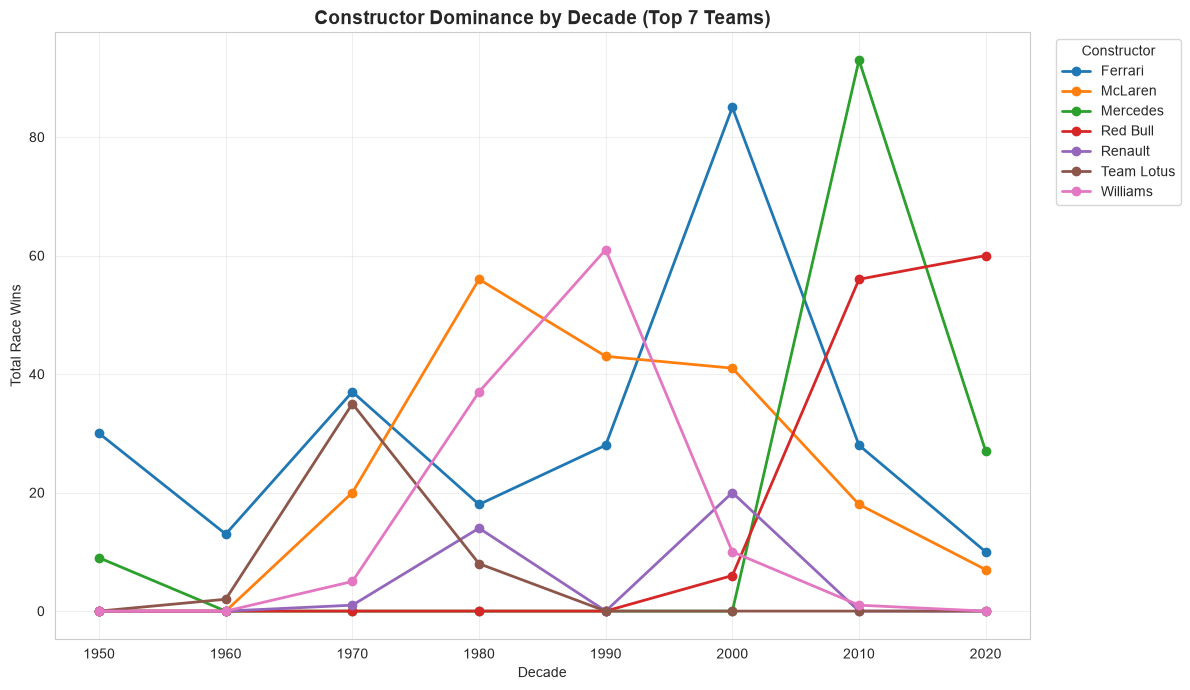

In [21]:
plt.figure(figsize=(12, 7))

for constructor in pivot.columns:
    plt.plot(pivot.index, pivot[constructor], marker='o', label=constructor, linewidth=2)

plt.title('Constructor Dominance by Decade (Top 7 Teams)', fontsize=14, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('Total Race Wins')
plt.legend(title='Constructor', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
circuits = pd.read_csv('../data/raw/circuits.csv', na_values=['\\N'])

circuits_subset = circuits[['circuitId', 'name', 'location', 'country']].rename(columns={'name': 'circuit_name'})

master = master.merge(circuits_subset, on='circuitId', how='left')

print(master.shape)

(26759, 34)


In [23]:
master['classified'] = master['status'].str.contains('Finished|Lap', case=False, na=False)

In [24]:
print(master['classified'].value_counts())
print()
print(master['status'].value_counts().head(20))

classified
True     15161
False    11598
Name: count, dtype: int64

status
Finished              7674
+1 Lap                4037
Engine                2026
+2 Laps               1613
Accident              1062
Did not qualify       1025
Collision              854
Gearbox                810
Spun off               795
+3 Laps                731
Suspension             431
+4 Laps                405
Did not prequalify     331
Transmission           321
Electrical             316
Brakes                 254
Withdrew               248
+5 Laps                221
Clutch                 214
Not classified         172
Name: count, dtype: int64


circuit_name
Adelaide Street Circuit                  0.625000
Zolder                                   0.613475
Autódromo Internacional Nelson Piquet    0.608392
Brands Hatch                             0.582888
Circuit de Monaco                        0.546274
Watkins Glen                             0.536082
Autodromo Enzo e Dino Ferrari            0.527742
Kyalami                                  0.527668
Reims-Gueux                              0.523622
Autódromo Juan y Oscar Gálvez            0.511161
Autódromo do Estoril                     0.506812
Indianapolis Motor Speedway              0.493892
Hockenheimring                           0.493048
Circuit Park Zandvoort                   0.487614
Autodromo Nazionale di Monza             0.468954
Name: classified, dtype: float64


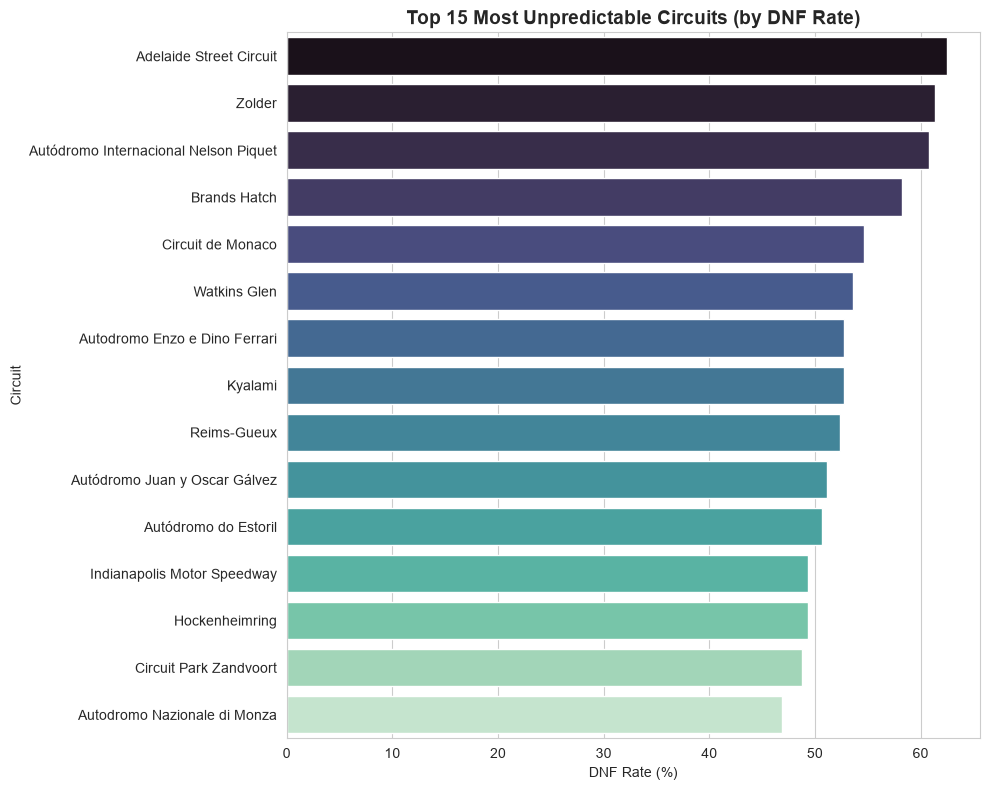

In [25]:
races_per_circuit = master.groupby('circuit_name')['raceId'].nunique()
valid_circuits = races_per_circuit[races_per_circuit >= 10].index

circuit_dnf = master.groupby('circuit_name')['classified'].mean()
circuit_dnf = 1 - circuit_dnf
circuit_dnf = circuit_dnf[circuit_dnf.index.isin(valid_circuits)]
top_chaotic = circuit_dnf.sort_values(ascending=False).head(15)
print(top_chaotic)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_chaotic.values * 100, y=top_chaotic.index, palette='mako', hue=top_chaotic.index, legend=False)
plt.title('Top 15 Most Unpredictable Circuits (by DNF Rate)', fontsize=14, fontweight='bold')
plt.xlabel('DNF Rate (%)')
plt.ylabel('Circuit')
plt.tight_layout()
plt.show()

              grid  position    points      laps
grid      1.000000  0.665602 -0.566062  0.018710
position  0.665602  1.000000 -0.654731 -0.063213
points   -0.566062 -0.654731  1.000000 -0.024968
laps      0.018710 -0.063213 -0.024968  1.000000


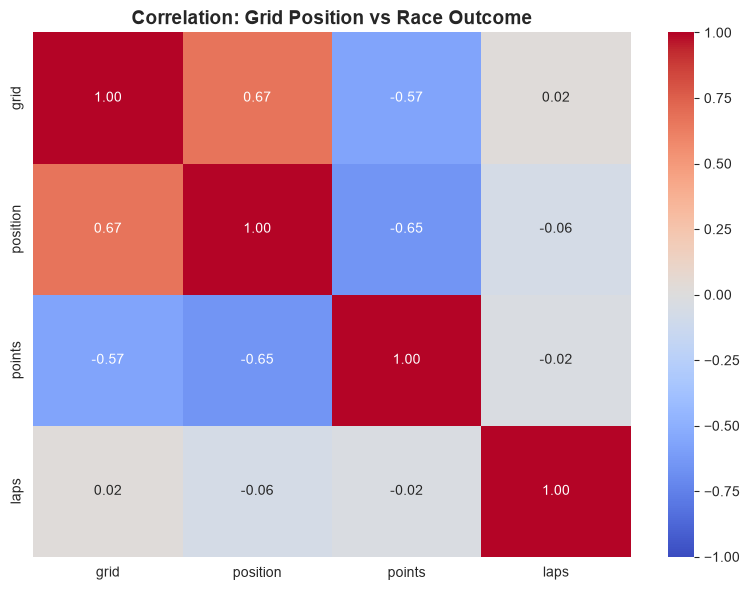

In [26]:
finished = master[master['classified'] == True]
corr_data = finished[['grid', 'position', 'points', 'laps']].corr()
print(corr_data)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1, center=0)
plt.title('Correlation: Grid Position vs Race Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
lap_times = pd.read_csv("../data/raw/lap_times.csv", na_values=["\\N"])
pit_stops = pd.read_csv("../data/raw/pit_stops.csv", na_values=["\\N"])

print(lap_times.shape)
lap_times.head()

(589081, 6)


,raceId,driverId,lap,position,time,milliseconds
0,841,20,1,1,1:38.109,98109
1,841,20,2,1,1:33.006,93006
2,841,20,3,1,1:32.713,92713
3,841,20,4,1,1:32.803,92803
4,841,20,5,1,1:32.342,92342


In [28]:
races[races["year"] == 2021] [["raceId","name","round"]]

,raceId,name,round
1035,1053,Emilia Romagna Grand Prix,2
1037,1052,Bahrain Grand Prix,1
1038,1051,Qatar Grand Prix,20
1039,1054,Portuguese Grand Prix,3
1040,1055,Spanish Grand Prix,4
1041,1056,Monaco Grand Prix,5
1042,1057,Azerbaijan Grand Prix,6
1043,1058,Styrian Grand Prix,8
1044,1059,French Grand Prix,7
1045,1060,Austrian Grand Prix,9


In [46]:
chosen_race = 1073
race_laps = lap_times[lap_times['raceId'] == chosen_race]

In [47]:
hamilton_id = drivers[drivers['driverRef'] == 'hamilton']['driverId'].values[0]

In [48]:
hamilton_laps = race_laps[race_laps['driverId'] == hamilton_id].sort_values('lap')

In [49]:
hamilton_stops = pit_stops[(pit_stops['raceId'] == chosen_race) & (pit_stops['driverId'] == hamilton_id)]

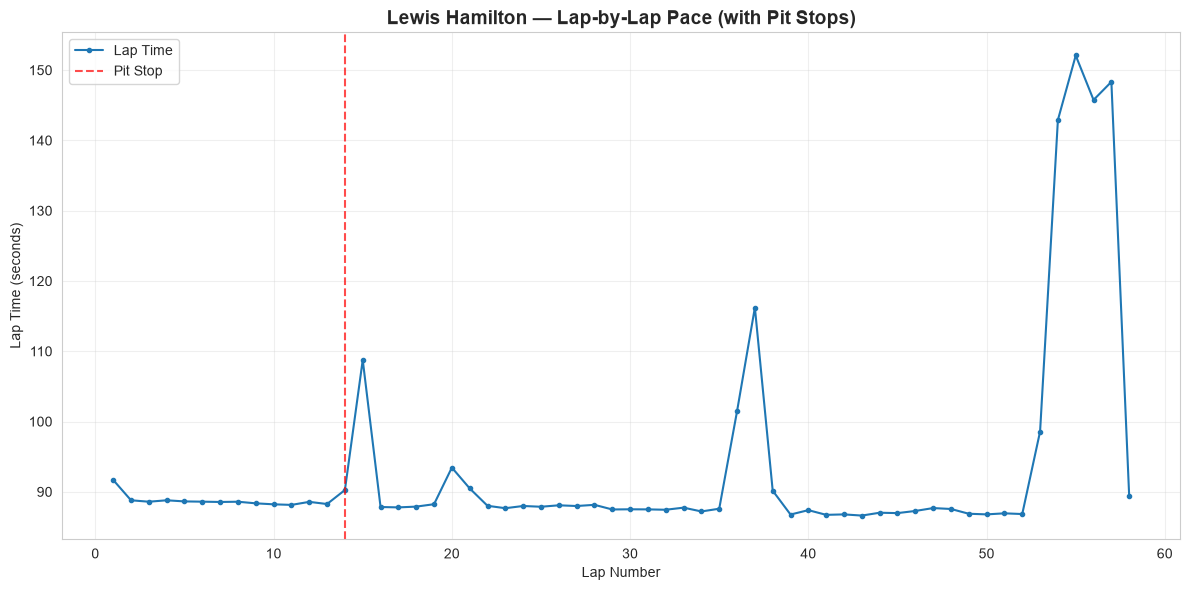

In [50]:
plt.figure(figsize=(12, 6))
plt.plot(hamilton_laps['lap'], hamilton_laps['milliseconds'] / 1000, marker='o', markersize=3, label='Lap Time')

for stop_lap in hamilton_stops['lap']:
    plt.axvline(x=stop_lap, color='red', linestyle='--', alpha=0.7, label='Pit Stop' if stop_lap == hamilton_stops['lap'].iloc[0] else "")

plt.title('Lewis Hamilton — Lap-by-Lap Pace (with Pit Stops)', fontsize=14, fontweight='bold')
plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

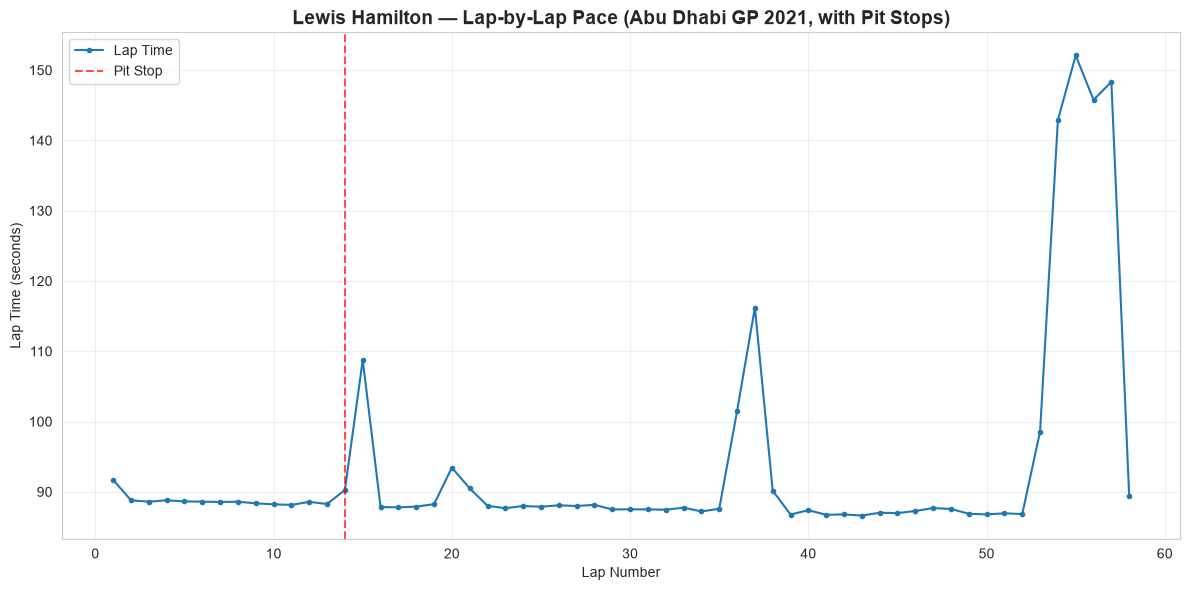

In [45]:
chosen_race = 1073

race_laps = lap_times[lap_times['raceId'] == chosen_race]

hamilton_id = drivers[drivers['driverRef'] == 'hamilton']['driverId'].values[0]
hamilton_laps = race_laps[race_laps['driverId'] == hamilton_id].sort_values('lap')

hamilton_stops = pit_stops[(pit_stops['raceId'] == chosen_race) & (pit_stops['driverId'] == hamilton_id)]

plt.figure(figsize=(12, 6))
plt.plot(hamilton_laps['lap'], hamilton_laps['milliseconds'] / 1000, marker='o', markersize=3, label='Lap Time')

for stop_lap in hamilton_stops['lap']:
    plt.axvline(x=stop_lap, color='red', linestyle='--', alpha=0.7, label='Pit Stop' if stop_lap == hamilton_stops['lap'].iloc[0] else "")

plt.title('Lewis Hamilton — Lap-by-Lap Pace (Abu Dhabi GP 2021, with Pit Stops)', fontsize=14, fontweight='bold')
plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [51]:
pit_stops_with_race = pit_stops.merge(races[['raceId', 'year']], on='raceId', how='left')
pit_stops_with_race = pit_stops_with_race.merge(results[['raceId', 'driverId', 'constructorId']], on=['raceId', 'driverId'], how='left')
pit_stops_with_race = pit_stops_with_race.merge(constructors[['constructorId', 'name']].rename(columns={'name': 'constructor_name'}), on='constructorId', how='left')

recent_stops = pit_stops_with_race[pit_stops_with_race['year'] >= 2011]

In [52]:
recent_stops = recent_stops[recent_stops['milliseconds'] < 60000]

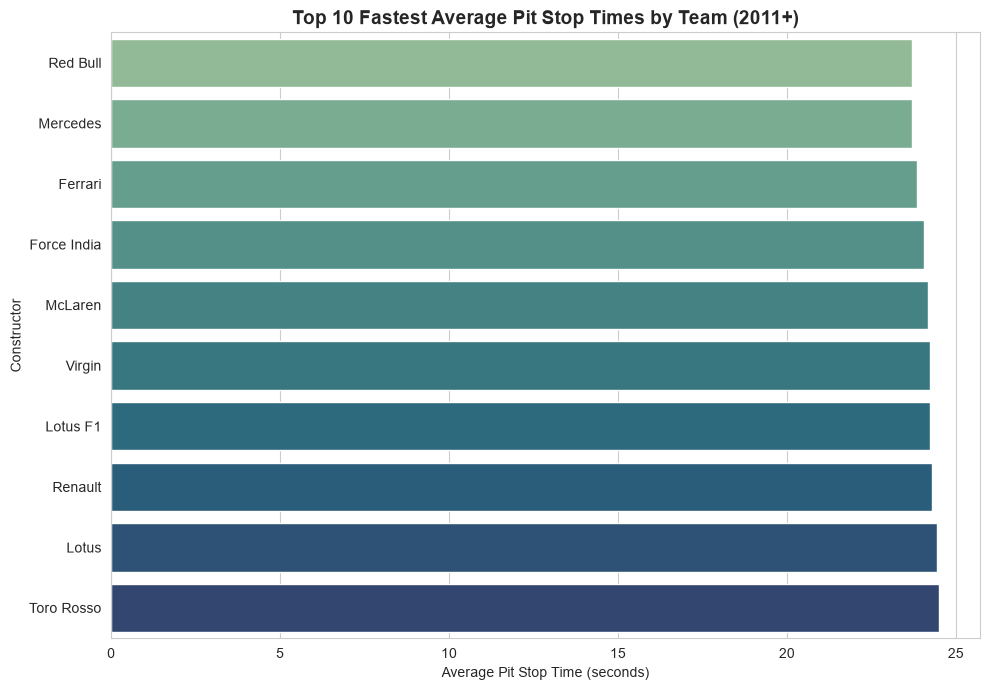

In [53]:
avg_pit_time = recent_stops.groupby('constructor_name')['milliseconds'].mean().sort_values() / 1000
top_fastest = avg_pit_time.head(10)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_fastest.values, y=top_fastest.index, palette='crest', hue=top_fastest.index, legend=False)
plt.title('Top 10 Fastest Average Pit Stop Times by Team (2011+)', fontsize=14, fontweight='bold')
plt.xlabel('Average Pit Stop Time (seconds)')
plt.ylabel('Constructor')
plt.tight_layout()
plt.show()

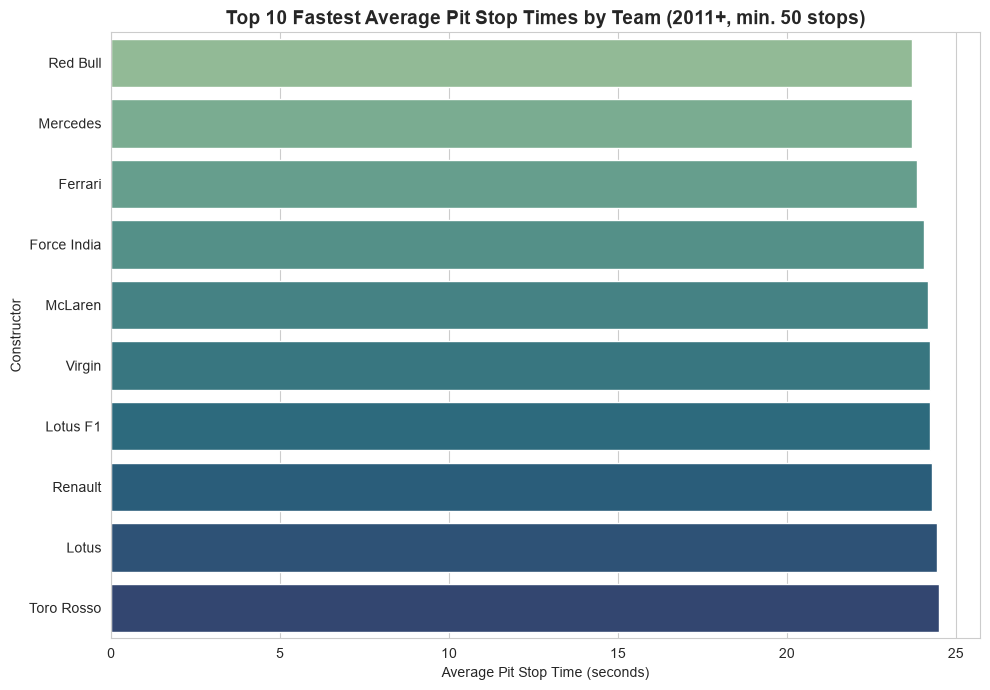

In [54]:
stop_counts = recent_stops.groupby('constructor_name')['milliseconds'].count()
valid_teams = stop_counts[stop_counts >= 50].index

filtered_stops = recent_stops[recent_stops['constructor_name'].isin(valid_teams)]
avg_pit_time_filtered = filtered_stops.groupby('constructor_name')['milliseconds'].mean().sort_values() / 1000
top_fastest_filtered = avg_pit_time_filtered.head(10)

plt.figure(figsize=(10, 7))
sns.barplot(x=top_fastest_filtered.values, y=top_fastest_filtered.index, palette='crest', hue=top_fastest_filtered.index, legend=False)
plt.title('Top 10 Fastest Average Pit Stop Times by Team (2011+, min. 50 stops)', fontsize=14, fontweight='bold')
plt.xlabel('Average Pit Stop Time (seconds)')
plt.ylabel('Constructor')
plt.tight_layout()
plt.show()